# Simulations from Shaer et al. 

In [276]:
import numpy as np

def generate_dataset(n, beta=1.0, d=19, seed=None):
    rng = np.random.default_rng(seed)

    # Fixed parameters: IMPORTANT TO NORMALIZE THESE TO KEEP "EFFECT SIZE" FIXED!
    '''W = rng.normal(size=d)
    W /= np.sum(np.abs(W))
    U = rng.normal(size=d)
    U /= np.sum(np.abs(U))'''

    # Correct way of uniformly sampling a convex combination
    W = np.random.dirichlet(np.ones(d), size=1).flatten()
    U = np.random.dirichlet(np.ones(d), size=1).flatten()

    # Generate Z ~ N(0, I_d)
    Z = rng.normal(size=(n, d))

    # Generate X | Z ~ N(U^T Z, 1)
    X = Z @ U + rng.normal(size=n)

    # Generate Y
    epsilon = rng.normal(size=n)
    Y = (Z @ W) ** 2 + beta * X + epsilon

    # Design matrix: first column is X, remaining columns are Z
    X_design = np.column_stack((X, Z))

    return X_design, Y

In [ ]:
import os

os.chdir("..")
os.getcwd()

'c:\\Users\\sebas\\Desktop\\sequential_ml_testing\\src'

In [ ]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from Sampler import DefaultSampler
from copy import deepcopy
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign
from utils import prepare_kernel_density_parameters, g_family_kde, update_g_func_kernel_density, initialize_kde_history, generate_update_kde
from tqdm import tqdm
import pickle

etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

batch_list = [25]
j_vec = [0]
'''e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )'''

### INCLUDING KDE
window_size = None
updater_kde = generate_update_kde(resamplings=20, window_size=window_size)

bets_js_bs = {
            j: {
                b: {
                    key: deepcopy(strategy)
                    for key, strategy in betting_strategies.items()
                }
                for b in batch_list
            }
            for j in j_vec
        }
sampdoria = [DefaultSampler(j=j) for j in j_vec]

n_init = 2000
num_seeds = 5
martingales_per_seed=[]
b_resamplings = 50
betas = [0.3]

for beta in betas:
    martingales_per_seed = []
    for seed in tqdm(range(num_seeds)):
        np.random.seed(seed)               ### REMOVED SEED !!
        X, Y = generate_dataset(2250, beta=beta, d=19, seed=None) ## CHANGED d VALUE HERE

        q, q_tilde = initialize_kde_history(X[:n_init], Y[:n_init].ravel(), sampdoria, j_vec, batch_list, model = LassoCV())

        for j in j_vec:
            for b in batch_list:
                params_kde = prepare_kernel_density_parameters()
                model_for_history = LassoCV()
                sampdoria = [DefaultSampler(j=j)]
                
                past_qs = list(zip(q[b], q_tilde[b][j]))
                strategy_kde = AntisymmetricBet(
                    g_family= g_family_kde, 
                    update_g_func = updater_kde, 
                    parameters=params_kde,
                    prequential=True,
                    past_qs = past_qs
                )
                bets_js_bs[j][b]["kde"] = strategy_kde


        e_process = ML_e_process(batch_list=batch_list, n_init=n_init, b_resamplings=b_resamplings, study_j=j_vec,
                        betting_strategies=betting_strategies, model=LassoCV(),
                        #learn_conditional_distribution=get_data_statistics,
                        samplers=None, #sampling_args={}
                        learn_conditional_distribution=True,
                        optional_stopping=True, 
                        bets_js_bs=bets_js_bs
                        )
        # maybe we can plot the (l,l_hat) density

        martingales_per_seed.append(e_process.martingales(X, y=Y))
    with open(f'testing_kde_1k_pretraining_batch_25_b_resamplings_{b_resamplings}_beta_{beta}.pkl', 'wb') as f:
        pickle.dump(martingales_per_seed, f)


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [04:18<00:00, 51.67s/it]


Conclusions of ANALYSIS WITHOUT KDE (with U,W gaussian/sum(abs())):
- Dividing W and U during data generation with sum(abs()) makes the experiment much less volatile
- For batch_size=25, beta >= 0.2 exp is the clear favorite, lin, tanh and sign_preq are in second place all almost equal, uniform sign sucks
- For batch_size = 25, 0.1 < \beta < 0.15 exp becomes the worst, CB and sign_preq are best. Below 0.1 basically no rejections.

- For different batch sizes:
- Q: does batch size need to divide pretraining dataset size?

Conclusions (with U,W uniformly sampled conv combinations):
- More or less the same as above but cutoff point beta = 0.3.

In [320]:
beta = 0.3
b_resamplings = 50
with open(f'testing_kde_1k_pretraining_batch_25_b_resamplings_{b_resamplings}_beta_{beta}.pkl', 'rb') as f:
    martingales_per_seed = pickle.load(f)

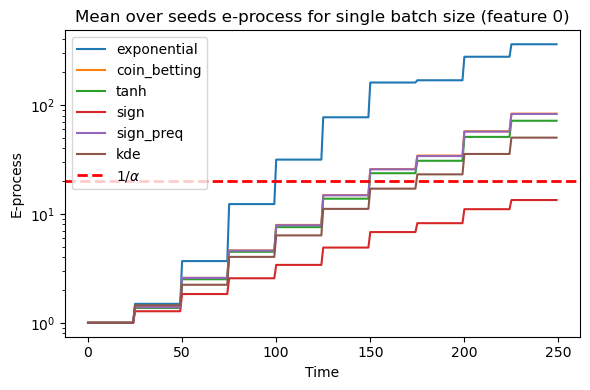

In [321]:
import matplotlib.pyplot as plt
alpha = 0.05

#martingales = martingales_per_seed[9]

plt.figure(figsize=(6, 4))
j=0
batch_size = 25 # 10 or 25

strategy_names = ['exponential','coin_betting','tanh','sign','sign_preq','kde']
antisymmetric_strategy_names = ['coin_betting','tanh','sign','sign_preq','kde']

for strategy_name in strategy_names:
    # average over seeds
    plt.plot(np.mean([martingales_per_seed[i][strategy_name][batch_size][j][n_init:] for i in range(num_seeds)],axis=0), label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean over seeds e-process for single batch size (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

# More complex models

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor


e_process_gb = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=GradientBoostingRegressor(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )

In [10]:
martingales_gb = e_process_gb.martingales(X, y=Y)

/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), 

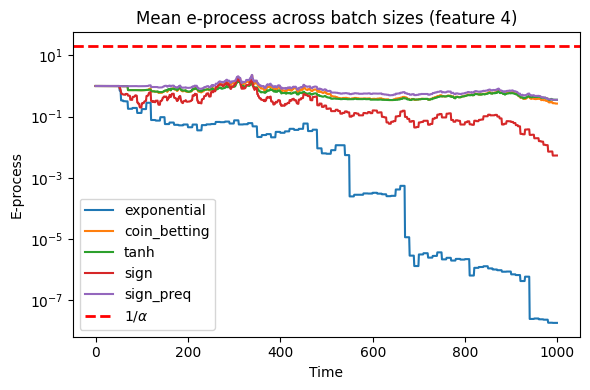

In [24]:
j = 4
plt.figure(figsize=(6, 4))

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales_gb[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()